In [50]:
import numpy as np
import pandas as pd
from ast import literal_eval

import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, pairwise_distances
from sklearn.preprocessing import StandardScaler, normalize, MultiLabelBinarizer
#from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
scryfall_df = pd.read_csv('./data/final-scryfall-unique-artwork.csv')

scryfall_df.head()

,id,oracle_id,name,set_id,set,set_name,artist_ids,artist,released_at,type_line,...,power,toughness,edhrec_rank,type,subtype,legality_commander,legality_standard,price_usd,image_uri_normal,image_uri_art_crop
0,0000419b-0bba-4488-8f7a-6194544ce91e,b34bb2dc-c1af-4d77-b0b3-a0fb342a5fc6,Forest,a2f58272-bba6-439d-871e-7a46686ac018,blb,Bloomburrow,['22ab27e3-6476-48f1-a9f7-9a9e86339030'],David Robert Hovey,2024-08-02,Basic Land — Forest,...,NaN,NaN,NaN,Basic Land,Forest,legal,legal,0.25,https://cards.scryfall.io/normal/front/0/0/000...,https://cards.scryfall.io/art_crop/front/0/0/0...
1,0000579f-7b35-4ed3-b44c-db2a538066fe,44623693-51d6-49ad-8cd7-140505caf02f,Fury Sliver,c1d109bc-ffd8-428f-8d7d-3f8d7e648046,tsp,Time Spiral,['d48dd097-720d-476a-8722-6a02854ae28b'],Paolo Parente,2006-10-06,Creature — Sliver,...,3,3,9808.0,Creature,Sliver,legal,not_legal,0.46,https://cards.scryfall.io/normal/front/0/0/000...,https://cards.scryfall.io/art_crop/front/0/0/0...
2,00006596-1166-4a79-8443-ca9f82e6db4e,8ae3562f-28b7-4462-96ed-be0cf7052ccc,Kor Outfitter,eb16a2bd-a218-4e4e-8339-4aa1afc0c8d2,zen,Zendikar,['aa7e89ed-d294-4633-9057-ce04dacfcfa4'],Kieran Yanner,2009-10-02,Creature — Kor Soldier,...,2,2,19672.0,Creature,Kor Soldier,legal,not_legal,0.11,https://cards.scryfall.io/normal/front/0/0/000...,https://cards.scryfall.io/art_crop/front/0/0/0...
3,0000cd57-91fe-411f-b798-646e965eec37,9f0d82ae-38bf-45d8-8cda-982b6ead1d72,Siren Lookout,fe0dad85-54bc-4151-9200-d68da84dd0f2,xln,Ixalan,['a8e7b854-b15a-421a-b66d-6e68187ae285'],Chris Rallis,2017-09-29,Creature — Siren Pirate,...,1,2,18843.0,Creature,Siren Pirate,legal,not_legal,0.04,https://cards.scryfall.io/normal/front/0/0/000...,https://cards.scryfall.io/art_crop/front/0/0/0...
4,0001f1ef-b957-4a55-b47f-14839cdbab6f,ef027846-be81-4959-a6b5-56bd01b1e68a,Venerable Knight,a90a7b2f-9dd8-4fc7-9f7d-8ea2797ec782,eld,Throne of Eldraine,['9c201dbe-db56-429a-87e6-189ea70c2632'],Colin Boyer,2019-10-04,Creature — Human Knight,...,2,1,18404.0,Creature,Human Knight,legal,not_legal,0.15,https://cards.scryfall.io/normal/front/0/0/000...,https://cards.scryfall.io/art_crop/front/0/0/0...


In [3]:
scryfall_df.columns

Index(['id', 'oracle_id', 'name', 'set_id', 'set', 'set_name', 'artist_ids',
       'artist', 'released_at', 'type_line', 'keywords', 'rarity',
       'color_identity', 'cmc', 'power', 'toughness', 'edhrec_rank', 'type',
       'subtype', 'legality_commander', 'legality_standard', 'price_usd',
       'image_uri_normal', 'image_uri_art_crop'],
      dtype='str')

In [4]:
final_df = scryfall_df.copy()

final_df['rarity'] = final_df['rarity'].map({'common':0, 'special':0.5, 'uncommon':1, 'rare':2, 'mythic':3})
final_df['legality_commander'] = final_df['legality_commander'].map({'legal': 1, 'banned': 0.5, 'not_legal': 0})
final_df['legality_standard'] = final_df['legality_standard'].map({'legal': 1, 'banned': 0.5, 'not_legal': 0})
final_df.color_identity = final_df.color_identity.replace(to_replace=['[]'], value="['N']")

#final_df = final_df[(final_df['toughness'].str.isnumeric()) & (final_df['power'].str.isnumeric())]
final_df = final_df[final_df['edhrec_rank'].notna()]

In [5]:
creature_df = final_df[final_df['type'].str.contains('Creature')]
creature_df['price_usd'].describe()

count    19450.000000
mean         5.444740
std         88.884708
min          0.010000
25%          0.090000
50%          0.190000
75%          0.710000
max       7618.212000
Name: price_usd, dtype: float64

In [6]:
# calculate thresholds for top 1%, bottom 1%, and middle 1% by price
creature_df.loc[:,'price_usd'] = creature_df['price_usd'].round(2)

top_1 = creature_df['price_usd'].quantile(0.99)
bottom_1 = creature_df['price_usd'].quantile(0.01)
mid_lower = creature_df['price_usd'].quantile(0.495) # just below median
mid_upper = creature_df['price_usd'].quantile(0.505) # just above median

top_1_df = creature_df[creature_df['price_usd'] >= top_1]
top_1_df['percentile'] = 'Top 1%'

bottom_1_df = creature_df[creature_df['price_usd'] <= bottom_1]
bottom_1_df['percentile'] = 'Bottom 1%'

mid_1_df = creature_df[(creature_df['price_usd'] >= mid_lower) & (creature_df['price_usd'] < mid_upper)]
mid_1_df['percentile'] = 'Middle 1%'

percentile_df = pd.concat([top_1_df, bottom_1_df, mid_1_df]).reset_index()
print(len(percentile_df))

510


In [7]:
one_hot_encoding_df = percentile_df.copy()
one_hot_encoding_df['subtype'] = percentile_df['subtype'].fillna('').str.split()

In [8]:
mlb = MultiLabelBinarizer()
encoded_subtypes = mlb.fit_transform(one_hot_encoding_df['subtype'])
subtypes_df = pd.DataFrame(encoded_subtypes, columns='s_'+mlb.classes_, index=one_hot_encoding_df.index)
subtypes_df.head()

,s_Advisor,s_Aetherborn,s_Ally,s_Angel,s_Antelope,s_Archer,s_Artificer,s_Assassin,s_Avatar,s_Badger,...,s_Warlock,s_Warrior,s_Whale,s_Wizard,s_Wolf,s_Wolverine,s_Wraith,s_Wurm,s_Yeti,s_Zombie
0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
encoded_keywords = mlb.fit_transform(one_hot_encoding_df['keywords'].apply(literal_eval))
keywords_df = pd.DataFrame(encoded_keywords, columns='k_'+mlb.classes_, index=one_hot_encoding_df.index)
keywords_df.head()

,k_Afterlife,k_Amass,k_Ascend,k_Assist,k_Banding,k_Battle Cry,k_Blitz,k_Bloodrush,k_Bloodthirst,k_Boast,...,k_Swampcycling,k_Swampwalk,k_Trample,k_Treasure,k_Typecycling,k_Unleash,k_Vigilance,k_Void,k_Ward,k_Warp
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
encoded_colors = mlb.fit_transform(one_hot_encoding_df['color_identity'].apply(literal_eval))
colors_df = pd.DataFrame(encoded_colors, columns='c_'+mlb.classes_, index=one_hot_encoding_df.index)
colors_df.head()

,c_B,c_G,c_N,c_R,c_U,c_W
0,0,1,0,0,0,0
1,0,1,0,0,0,0
2,1,1,0,1,1,1
3,0,0,0,1,0,0
4,0,0,0,0,1,0


In [11]:
features = pd.concat([subtypes_df, keywords_df, colors_df], axis=1)
features.head()

,s_Advisor,s_Aetherborn,s_Ally,s_Angel,s_Antelope,s_Archer,s_Artificer,s_Assassin,s_Avatar,s_Badger,...,k_Vigilance,k_Void,k_Ward,k_Warp,c_B,c_G,c_N,c_R,c_U,c_W
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,1,1,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [54]:
distance_matrix = pairwise_distances(features.to_numpy(), metric='jaccard')
distance_matrix

c:\Users\sophc\Desktop\MTG Project\understanding-mtg-card-value-through-ml\.venv\Lib\site-packages\sklearn\metrics\pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


array([[0.        , 0.66666667, 0.8       , ..., 1.        , 0.85714286,
        0.875     ],
       [0.66666667, 0.        , 0.75      , ..., 1.        , 1.        ,
        0.83333333],
       [0.8       , 0.75      , 0.        , ..., 0.875     , 0.88888889,
        0.9       ],
       ...,
       [1.        , 1.        , 0.875     , ..., 0.        , 0.75      ,
        1.        ],
       [0.85714286, 1.        , 0.88888889, ..., 0.75      , 0.        ,
        1.        ],
       [0.875     , 0.83333333, 0.9       , ..., 1.        , 1.        ,
        0.        ]], shape=(510, 510))

In [ ]:
X_embedded = TSNE(n_components=2, learning_rate='auto', random_state=42,
                  init='random', perplexity=3).fit_transform(distance_matrix)
X_embedded

array([[ 38.554195 , -22.009768 ],
       [ 48.60284  , -17.02769  ],
       [  9.023827 ,  25.149237 ],
       ...,
       [-27.359676 ,  52.347576 ],
       [ 37.42325  ,  41.88104  ],
       [ 23.043032 ,  -1.5753294]], shape=(510, 2), dtype=float32)

In [109]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(abs(scaler.fit_transform(X_embedded)))
X_scaled = X_scaled.rename(columns={0:'A', 1:'B'})

#X_normalized = normalize(X_scaled)
#X_normalized = pd.DataFrame(X_normalized)

#X_normalized.head()

X_scaled

,A,B
0,0.965823,0.579811
1,1.219766,0.454929
2,0.219550,0.602288
3,0.699696,1.333816
4,0.384787,0.096469
...,...,...
505,1.348788,0.413282
506,0.489139,1.570675
507,0.699910,1.284048
508,0.937242,1.021691


In [110]:
db_clustering = DBSCAN(eps=0.15, min_samples=17, metric='euclidean')
db_clustering.fit(X_scaled)

labels = db_clustering.labels_
label_count = np.unique_counts(labels)
print(label_count.values, label_count.counts)

X_scaled['dbscan'] = labels
X_scaled

[-1  0  1  2  3  4  5  6] [180  57 146  52  19  19  19  18]


,A,B,dbscan
0,0.965823,0.579811,0
1,1.219766,0.454929,0
2,0.219550,0.602288,1
3,0.699696,1.333816,-1
4,0.384787,0.096469,2
...,...,...,...
505,1.348788,0.413282,0
506,0.489139,1.570675,-1
507,0.699910,1.284048,-1
508,0.937242,1.021691,1


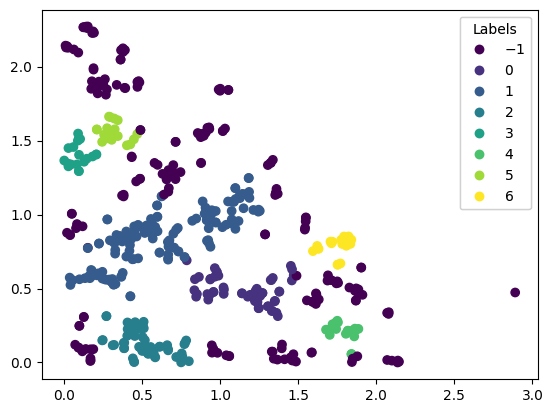

In [112]:
fig, ax = plt.subplots()

scatter = ax.scatter(X_scaled['A'], X_scaled['B'], c=X_scaled['dbscan'])

legend1 = ax.legend(*scatter.legend_elements(),
                    loc="upper right", title="Labels")
ax.add_artist(legend1)

plt.show()

In [113]:
sil_score = silhouette_score(X_scaled, labels)
print("Silhouette Coefficient: %0.2f" % sil_score)
db_score = davies_bouldin_score(X_scaled, labels)
print("Davies Bouldin Score: %0.2f" % db_score)
ch_score = calinski_harabasz_score(X_scaled, labels)
print("Calinski Harabasz Score: %0.2f" % ch_score)

Silhouette Coefficient: 0.54
Davies Bouldin Score: 0.46
Calinski Harabasz Score: 679.61
